# Preprocessing of dataset

Labels found: [0 1 2 3 4 5 6]


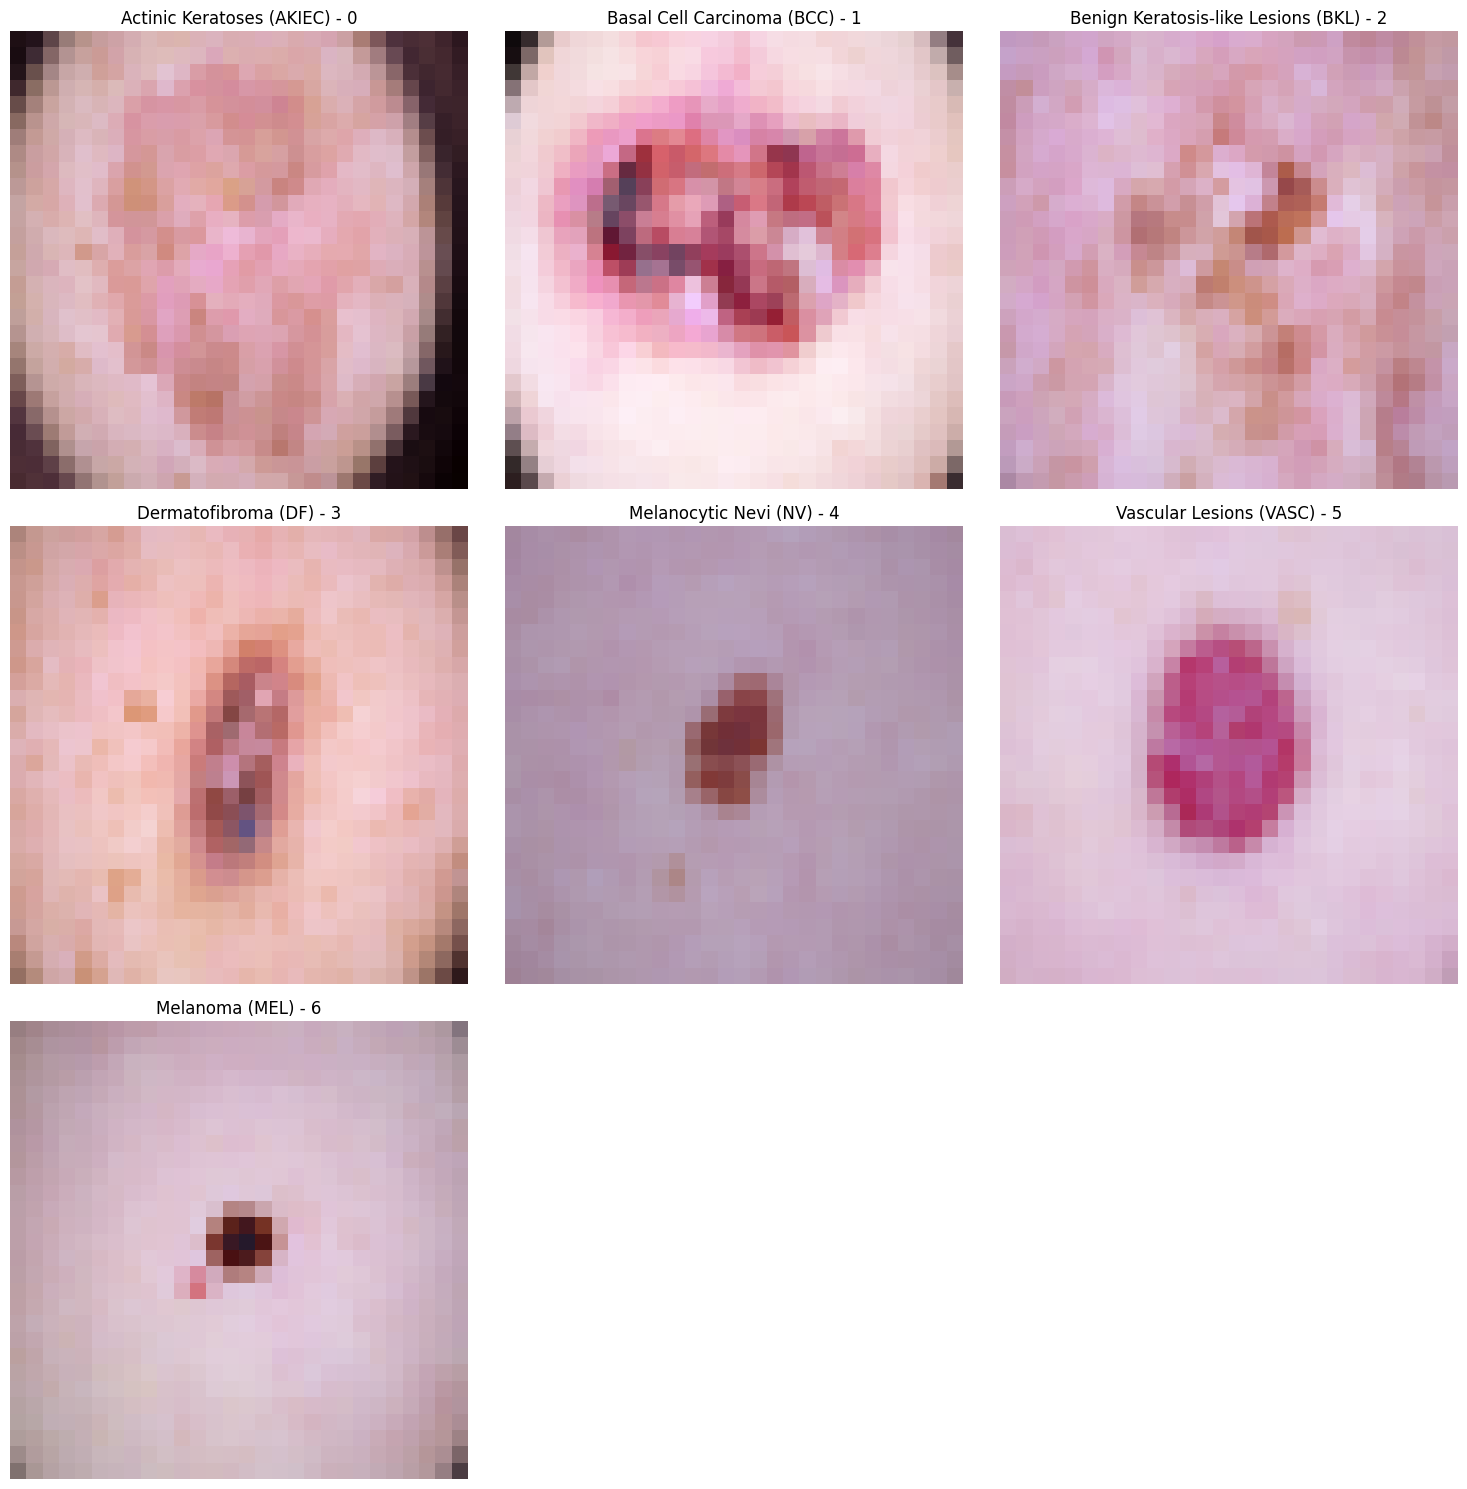

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load CSV
df = pd.read_csv("archive6/hmnist_28_28_RGB.csv")

# 2. Separate features and labels
X = df.drop("label", axis=1).values   # pixel columns
y = df["label"].values                # labels

# 3. Label mapping (numeric → lesion name)
label_map = {
    0: "Actinic Keratoses (AKIEC)",
    1: "Basal Cell Carcinoma (BCC)",
    2: "Benign Keratosis-like Lesions (BKL)",
    3: "Dermatofibroma (DF)",
    4: "Melanocytic Nevi (NV)",
    5: "Vascular Lesions (VASC)",
    6: "Melanoma (MEL)"
}

# 4. Find unique labels
unique_labels = np.unique(y)
print("Labels found:", unique_labels)

# 5. Display one image per label, 3 images per row
cols = 3
rows = int(np.ceil(len(unique_labels) / cols))
plt.figure(figsize=(5 * cols, 5 * rows))  # width and height proportional to grid

for i, label in enumerate(unique_labels):
    idx = np.where(y == label)[0][0]  # first occurrence of this label
    img = X[idx].reshape(28, 28, 3).astype(np.uint8)
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"{label_map[label]} - {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [25]:
import pandas as pd

# Load CSV
df = pd.read_csv("archive6/hmnist_28_28_RGB.csv")

# Count number of samples per label
label_counts = df['label'].value_counts()

print(label_counts)


label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64


In [26]:
label_map = {
    0: "Actinic Keratoses (AKIEC)",
    1: "Basal Cell Carcinoma (BCC)",
    2: "Benign Keratosis-like Lesions (BKL)",
    3: "Dermatofibroma (DF)",
    4: "Melanocytic Nevi (NV)",
    5: "Vascular Lesions (VASC)",
    6: "Melanoma (MEL)"
}


# Model

In [27]:
# -----------------------
# Imports
# -----------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Load CSV
csv_path = "archive6/hmnist_28_28_RGB.csv"
df = pd.read_csv(csv_path)

# Separate features and labels
labels = df['label'].values
X = df.drop(columns=['label']).values
X = X.reshape(-1, 28, 28, 3).astype("float32") / 255.0
y = labels.astype(int)   # <-- this defines 'y'

X_limited = X
y_limited = y

X_flat = X_limited.reshape(X_limited.shape[0], -1)

In [13]:
X_limited, y_limited = [], []

for cls in np.unique(y):
    cls_indices = np.where(y == cls)[0]
    
    if cls in [0, 1, 2, 3]:
        n_samples = 1500
    else:
        n_samples = 1000
    
    selected_indices = cls_indices[:n_samples] if len(cls_indices) > n_samples else cls_indices
    X_limited.append(X[selected_indices])
    y_limited.append(y[selected_indices])

X_limited = np.concatenate(X_limited, axis=0)
y_limited = np.concatenate(y_limited, axis=0)


In [14]:
from imblearn.over_sampling import ADASYN
import numpy as np

# -----------------------
# Print before ADASYN
# -----------------------
print("Before ADASYN:")
unique_before, counts_before = np.unique(y_limited, return_counts=True)
for cls, count in zip(unique_before, counts_before):
    print(f"Class {cls}: {count} samples")

# -----------------------
# Apply ADASYN
# -----------------------
# Create a dict of target samples
target_samples = {0:1500, 1:1500, 2:1500, 3:1000, 4:1000, 5:1000, 6:1000}

# Flatten images for ADASYN
X_flat = X_limited.reshape(len(X_limited), -1)

adasyn = ADASYN(random_state=42, sampling_strategy=target_samples, n_neighbors=3)
X_res, y_res = adasyn.fit_resample(X_flat, y_limited)

# -----------------------
# Print after ADASYN
# -----------------------
print("\nAfter ADASYN:")
unique_after, counts_after = np.unique(y_res, return_counts=True)
for cls, before_count, after_count in zip(unique_before, counts_before, counts_after):
    synthetic_added = after_count - before_count
    print(f"Class {cls}: original={before_count}, after ADASYN={after_count}, synthetic added={synthetic_added}")

total_before = len(y_limited)
total_after = len(y_res)
synthetic_total = total_after - total_before

print(f"\nTotal samples before ADASYN: {total_before}")
print(f"Total samples after ADASYN: {total_after}")
print(f"Total synthetic samples added: {synthetic_total}")

# -----------------------
# 5. Reshape back to images
# -----------------------
X_res = X_res.reshape(-1, 28, 28, 3)
print(f"\nShape of resampled dataset: {X_res.shape}")


Before ADASYN:
Class 0: 327 samples
Class 1: 514 samples
Class 2: 1099 samples
Class 3: 115 samples
Class 4: 1000 samples
Class 5: 142 samples
Class 6: 1000 samples

After ADASYN:
Class 0: original=327, after ADASYN=1592, synthetic added=1265
Class 1: original=514, after ADASYN=1460, synthetic added=946
Class 2: original=1099, after ADASYN=1560, synthetic added=461
Class 3: original=115, after ADASYN=976, synthetic added=861
Class 4: original=1000, after ADASYN=1000, synthetic added=0
Class 5: original=142, after ADASYN=1025, synthetic added=883
Class 6: original=1000, after ADASYN=1000, synthetic added=0

Total samples before ADASYN: 4197
Total samples after ADASYN: 8613
Total synthetic samples added: 4416

Shape of resampled dataset: (8613, 28, 28, 3)


In [15]:
# -----------------------
# 3. Shuffle and Split
# -----------------------
np.random.seed(42)
indices = np.arange(X_res.shape[0])
np.random.shuffle(indices)

X_res = X_res[indices]
y_res = y_res[indices]

# 80% train, 10% val, 10% test
train_end = int(0.8 * len(X_res))
val_end = int(0.9 * len(X_res))

X_train, y_train = X_res[:train_end], y_res[:train_end]
X_val, y_val = X_res[train_end:val_end], y_res[train_end:val_end]
X_test, y_test = X_res[val_end:], y_res[val_end:]

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 6890, Val: 861, Test: 862


In [16]:
# Assuming y_train is already defined
num_classes = len(np.unique(y_train))

class_weights = {}
for cls in np.unique(y_train):
    cls_count = np.sum(y_train == cls)
    class_weights[cls] = len(y_train) / (num_classes * cls_count)

print("Class Weights:")
for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight:.4f}")


Class Weights:
Class 0: 0.7769
Class 1: 0.8406
Class 2: 0.7678
Class 3: 1.3002
Class 4: 1.2397
Class 5: 1.2018
Class 6: 1.2304


In [17]:
# -----------------------
# 5. Create tf.data.Dataset
# -----------------------
IMG_SIZE = 96
BATCH_SIZE = 16

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000).map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE)

# Residual Network

In [ ]:
from tensorflow.keras import layers, models

# -----------------------
# 1. Residual Block
# -----------------------
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x
    
    # First convolution
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Second convolution
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # Adjust shortcut if shape mismatch
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Add shortcut
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

# -----------------------
# 2. Build the ResNet model
# -----------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # 3 channels RGB

# Initial convolution
x = layers.Conv2D(32, (3,3), strides=1, padding='same', use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

# Residual blocks
x = residual_block(x, 32)
x = residual_block(x, 32)

x = residual_block(x, 64, stride=2)  # downsample
x = residual_block(x, 64)

x = residual_block(x, 128, stride=2) # downsample
x = residual_block(x, 128)

# Global average pooling
x = layers.GlobalAveragePooling2D()(x)

# Fully connected layers
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# -----------------------
# 3. Compile the model
# -----------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# Basic CNN

In [18]:
from tensorflow.keras import layers, models

# -----------------------
# 1. Build a basic CNN
# -----------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # 3 channels (RGB)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# -----------------------
# 2. Compile the model
# -----------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,813,895 (18.36 MB)

 Trainable params: 4,813,895 (18.36 MB)

 Non-trainable params: 0 (0.00 B)

# Basic cnn + batch Normalization

In [ ]:
from tensorflow.keras import layers, models

# -----------------------
# 1. Build CNN with Batch Normalization
# -----------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # 3 channels (RGB)

# 1st Conv Block
x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 2nd Conv Block
x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# 3rd Conv Block
x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Fully connected layers
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# -----------------------
# 2. Compile the model
# -----------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


# InceptionV3

In [22]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3

# -----------------------
# 1. Build Model using InceptionV3
# -----------------------
# Make sure IMG_SIZE >= 75 (InceptionV3 minimum input size)
base_model = InceptionV3(
    include_top=False,              # remove default FC layers
    weights='imagenet',             # use pretrained ImageNet weights
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base model (optional — for transfer learning)
base_model.trainable = True
for layer in base_model.layers[:-50]:  # freeze all except last 50
    layer.trainable = False

# Input layer
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass input through InceptionV3
x = base_model(inputs, training=False)

# Global pooling instead of Flatten (better for Inception)
x = layers.GlobalAveragePooling2D()(x)

# Fully connected layers (same as your CNN)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

# Output layer
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Create model
model = models.Model(inputs, outputs)

# -----------------------
# 2. Compile the model
# -----------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,329,127 (85.18 MB)

 Trainable params: 7,699,655 (29.37 MB)

 Non-trainable params: 14,629,472 (55.81 MB)

In [17]:
from tensorflow.keras import layers, models
from keras_cv.models import ViTDetBackbone  # ✅ lighter than ViTDetB

# -----------------------
# 1. Build Vision Transformer Model
# -----------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # your defined IMG_SIZE

# Pretrained ViT Backbone
vit_backbone = ViTDetBackbone(
    include_rescaling=True,
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Optional: freeze to save GPU memory
vit_backbone.trainable = False

# Feature extraction
x = vit_backbone(inputs)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Create model
model = models.Model(inputs, outputs)

# -----------------------
# 2. Compile the model
# -----------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_det_backbone_1             │ (None, 6, 6, 256)      │    86,493,440 │
│ (ViTDetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,561,031 (330.20 MB)

 Trainable params: 67,591 (264.03 KB)

 Non-trainable params: 86,493,440 (329.95 MB)

In [19]:
# -----------------------
# 6. Callbacks
# -----------------------
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    #ModelCheckpoint("best_effnet_skin.h5", save_best_only=True)
]

In [20]:
# 0.00025
# -----------------------
# 7. Training
# -----------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
431/431 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3617 - loss: 1.5178 - val_accuracy: 0.5331 - val_loss: 1.2525 - learning_rate: 0.0010
Epoch 2/25
431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5274 - loss: 1.1209 - val_accuracy: 0.6249 - val_loss: 0.9484 - learning_rate: 0.0010
Epoch 3/25
431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5936 - loss: 0.9694 - val_accuracy: 0.6516 - val_loss: 0.8746 - learning_rate: 0.0010
Epoch 4/25
431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6469 - loss: 0.8325 - val_accuracy: 0.6295 - val_loss: 0.8966 - learning_rate: 0.0010
Epoch 5/25
431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7022 - loss: 0.7179 - val_accuracy: 0.7387 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 6/25
431/431 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7446 - loss: 0.6169 - val_accuracy: 0.8107 - val_loss: 0.5523 - learning_rate: 0.0010
Epoch 7/25
431/431 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7727 - loss: 0.5445 

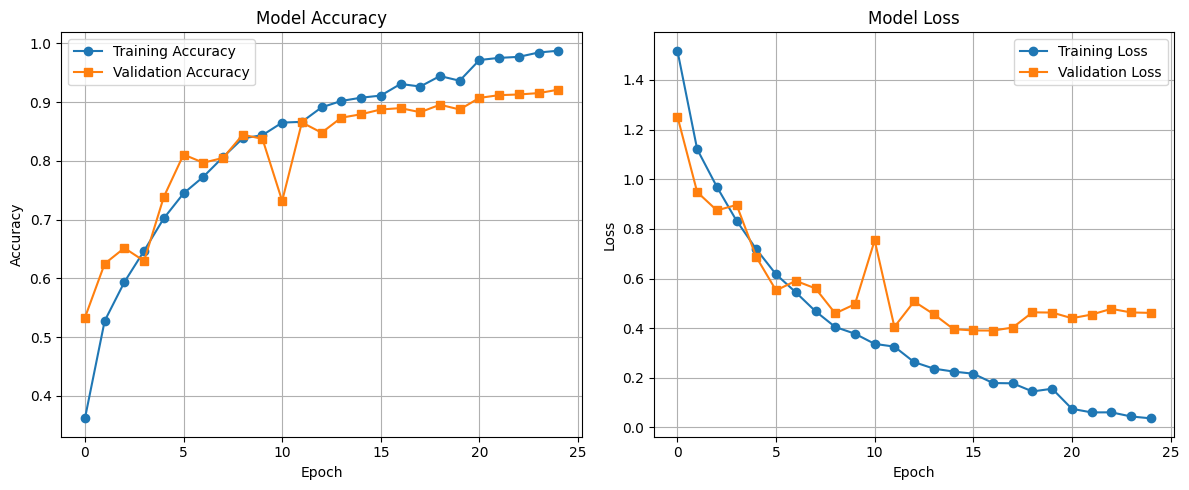

Final Training Accuracy: 0.9874
Final Validation Accuracy: 0.9210


In [21]:
import matplotlib.pyplot as plt

# Extract training history
acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

# Create subplots for accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy', marker='o')
plt.plot(val_acc, label='Validation Accuracy', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='s')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# -----------------------
# 9. Display Final Accuracy
# -----------------------
print(f"Final Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")


🏋️ Final Accuracy: 0.9874


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       157
           1       0.85      0.95      0.90       147
           2       0.72      0.78      0.75       145
           3       0.98      0.98      0.98       122
           4       0.97      0.87      0.92        95
           5       0.98      0.99      0.99       105
           6       0.73      0.59      0.65        91

    accuracy                           0.88       862
   macro avg       0.88      0.87      0.87       862
weighted avg       0.88      0.88      0.88       862



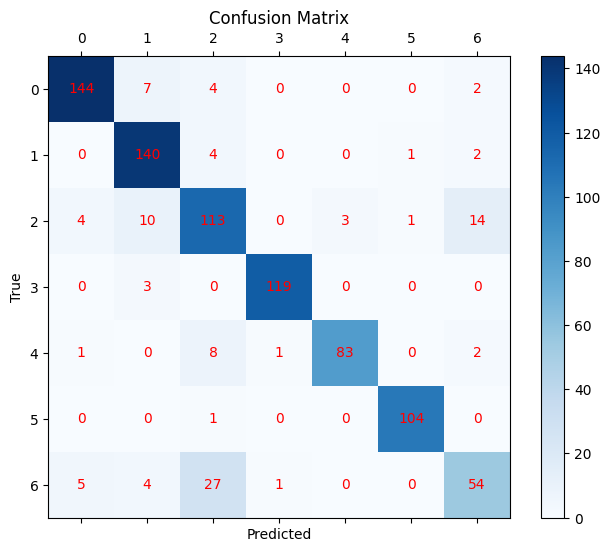

In [22]:
# -----------------------
# 9. Evaluation
# -----------------------
#test_loss, test_acc = model.evaluate(test_ds, verbose=0)
#print(f"\n🔥 Final Test Accuracy: {test_acc:.4f}")
final_train_acc = history.history['accuracy'][-1]
print(f"\n🏋️ Final Accuracy: {final_train_acc:.4f}")
# Predictions
y_pred = np.argmax(model.predict(test_ds), axis=1)

# Classification Report
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix using Matplotlib only
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
fig.colorbar(cax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

# Add text labels
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), va='center', ha='center', color="red")

plt.show()

In [23]:
model.save("inception_model.h5")

In [28]:
from PIL import Image
import pandas as pd
import numpy as np

# -----------------------
# 1. Load and crop image (zoom-in)
# -----------------------
img = Image.open('image.jpeg').convert('RGB')  # ensure RGB mode
width, height = img.size

# Resize cropped region to 28x28
img = img.resize((28, 28))

# -----------------------
# 2. Convert to NumPy array
# -----------------------
img_array = np.array(img)  # shape (28, 28, 3)

# -----------------------
# 3. Separate and flatten channels
# -----------------------
R = img_array[:, :, 0].flatten()  # Red channel
G = img_array[:, :, 1].flatten()  # Green channel
B = img_array[:, :, 2].flatten()  # Blue channel

# Combine in order: R → G → B
pixel_array = np.concatenate([R, G, B])

# -----------------------
# 4. Create DataFrame
# -----------------------
df = pd.DataFrame([pixel_array])
print(df.head())


   0     1     2     3     4     5     6     7     8     9     ...  2342  \
0   171   180   186   189   180   170   181   195   190   193  ...   166   

   2343  2344  2345  2346  2347  2348  2349  2350  2351  
0   163   154   158   172   167   158   161   163   156  

[1 rows x 2352 columns]


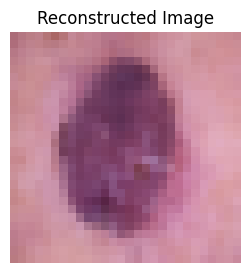

In [29]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Assume df already contains the flattened pixel data
pixels = df.iloc[0].to_numpy()

# Split into R, G, B channels
R = pixels[:784].reshape(28, 28)
G = pixels[784:1568].reshape(28, 28)
B = pixels[1568:].reshape(28, 28)

# Stack back into an RGB image
reconstructed = np.stack([R, G, B], axis=2).astype(np.uint8)

# Convert to PIL image
reconstructed_img = Image.fromarray(reconstructed)

# -----------------------
# ✅ Display using Matplotlib
# -----------------------
plt.figure(figsize=(3, 3))
plt.imshow(reconstructed_img)
plt.axis('off')  # hides axes
plt.title("Reconstructed Image")
plt.show()


In [30]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load model
#model = load_model("inception_model.h5")
model = load_model("basic_cnn_model.h5")


# Label map
label_map = {
    0: "Actinic Keratoses (AKIEC)",
    1: "Basal Cell Carcinoma (BCC)",
    2: "Benign Keratosis-like Lesions (BKL)",
    3: "Dermatofibroma (DF)",
    4: "Melanocytic Nevi (NV)",
    5: "Vascular Lesions (VASC)",
    6: "Melanoma (MEL)"
}

# -----------------------
# 1. Load & preprocess image
# -----------------------
img = image.load_img("image.jpeg", target_size=(96, 96))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # batch dimension
img_array = img_array / 255.0  # normalize to [0,1]

# -----------------------
# 2. Predict
# -----------------------
pred = model.predict(img_array)
predicted_class = np.argmax(pred, axis=1)[0]
confidence = np.max(pred)

print(f"🧾 Predicted: {label_map[predicted_class]}")
print(f"🎯 Confidence: {confidence:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
🧾 Predicted: Benign Keratosis-like Lesions (BKL)
🎯 Confidence: 0.9919


In [31]:
from tensorflow.keras.models import load_model

# Load your model
model = load_model("inception_model.h5")

# Print full architecture summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,813,897 (18.36 MB)

 Trainable params: 4,813,895 (18.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)